# Gemma replication — historical results, provenance fixes NOT RERUN

> **Status: every saved output, execution count, table, plot, and conclusion below belongs to
> the original unverified run, NOT to the revised code. No 31B rerun was performed.**
> The historical download saved `.pt.1` while the loader opened `.pt`; their identity was
> never established. These results cannot establish success or failure of a clean replication.
> Outputs are retained as an audit trail, including the old download/load logs. Restart the
> kernel and run all cells before interpreting new results; do not mix new and historical tables.

The revised load cell selects the exact Hub artifact at a resolved immutable commit and checks
its published LFS size/SHA-256 before loading. This fixes artifact selection, not unknown fitting
provenance. Revised code also fixes target scoring and lexical ranking; saved outputs are stale
and reflect NONE of these fixes. Old rank/result caches must be recomputed, not cast or reloaded.
This notebook always recomputes dataset metrics. The historical artifact cannot be recovered
from the old basename alone; resolving `main` now may select a different upstream version.


The full dataset analysis from `logit_lens_dataset.ipynb`, using the original **`jlens.LensModel`**
interface and **`jlens.from_hf` / `HFLensModel`** adapter. Change `MODEL_ID` to experiment with
supported HuggingFace causal models; no GPT-2 wrapper or private model members are used here.

The handwritten sanity checks below record raw block outputs and run
`readout(model, h_l)` for separate distribution logits and pre-softcap lexical scores.
The J-lens transports those **same activations** with `J_l` before
unembedding. Dataset evaluation performs one model forward per prompt. All metrics, controls,
plots, model correctness, and paired inner-layer comparisons are retained.

This recorded experiment selected `google/gemma-4-31B` in bfloat16.
Dataset prompts are evaluated as raw text completions; the notebook does not insert chat templates.

**Protocol** (`data/evaluations/README.md`):

* **readout position** — one token per prompt: the last prompt token (the one right before `target`,
  the closing period, the tail of the typo); for poetry — the newline at the end of the first line;
* **rank** — 1-based rank of a word among all tokens in the model’s vocabulary at that position, min over its single-token
  spellings (with/without leading space, case); for order-ops — min over the synonym set
  (numbers → digits and words, operations → symbols and words). Intermediate/control probes may
  fall back to first tokens; revised targets require complete single-token spellings. Unscorable
  targets have null ranks/correctness and are excluded with coverage reported. The historical
  outputs below used the old prefix-target scoring and do NOT reflect this correction;
* **pass@k** — mean over items of the fraction of `intermediates` whose min-over-layers rank ≤ k;
* **control** — the same ranks for the intermediates of *another* item of the same dataset.
  It is the chance level: a lens that surfaces any vaguely topical word scores here too.

**Tokenizer handling:** word spellings use `add_special_tokens=False`; fallback ranks use the
first lexical token, rather than an automatically inserted BOS. Agreement, copy rate, and KL
include all non-special prompt positions, including position 0 when there is no BOS. Vocabulary
size and layer count come from the chosen model. Ranks across different models need care because
their vocabularies and token segmentation differ.

**Two readout spaces:** lexical ranks use pre-softcap scores, descending score then ascending
token ID for exact ties. Accuracy, top-1 agreement, copy rate, and KL use the actual model
distribution. Softcap rounding can make lexical target hit@1 differ from model correctness;
the shared final lexical row is not a generated-answer metric. See `docs/readout_ranking.md`.


## Setup

In [ ]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# If opened within a repository clone, find its root in the parent directories.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "evaluation.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 22 (delta 11), reused 16 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (22/22), 246.12 KiB | 7.03 MiB/s, done.
From https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2
   1390b44..c2f6264  main               -> origin/main
 * [new branch]      latent-bridge-swap -> origin/latent-bridge-swap
Updating 1390b44..c2f6264
Fast-forward
 AGENTS.md                                          |    2 +
 data/experiments/README.md                         |    6 +
 data/experiments/latent-bridge.json                |  406 ++++
 jlens/evaluation.py                                |   58 +-
 jlens/strict_scoring.py                            |   92 +
 notebooks/jacobian_lens/concept_swap.ipynb         | 2077 +++++++++++++++++---
 .../pretrained_qwen_lens_dataset.ipynb             | 1255 ++++++++++++
 7 files changed, 3622 insertions(

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens import ActivationRecorder, HFLensModel, LensModel
from jlens.evaluation import (
    DATASETS,
    FIT_MIX,
    ROLE_NAMES,
    evaluate_paired,
    first_layer,
    fit_with_progress,
    identity_lens,
    layer_hit_rate,
    layer_mean,
    layer_median_rank,
    load_eval,
    load_fit_prompts,
    pass_at_k,
    plot_layer_curves,
    shown_layers,
)
from jlens.sharded_fitting import benchmark_dim_batches

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 240)

In [ ]:
# HISTORICAL download log below, retained for audit only; this cell no longer downloads.
# The revised load cell uses HUB_LENS and checks the exact returned artifact's size/SHA-256.
# It never opens gemma-4-31B_jacobian_lens.pt from the working directory.

--2026-10-08 11:42:57--  https://huggingface.co/neuronpedia/jacobian-lens/resolve/main/gemma-4-31b/jlens/Salesforce-wikitext/gemma-4-31B_jacobian_lens.pt
Resolving huggingface.co (huggingface.co)... 18.239.50.80, 18.239.50.49, 18.239.50.16, ...
Connecting to huggingface.co (huggingface.co)|18.239.50.80|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6a32e94f37ce0052330ad9bb/82caf79e9f377737e63265e586de8a11c4f3311dd73c89438204543e417f7d8b?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27gemma-4-31B_jacobian_lens.pt%3B+filename%3D%22gemma-4-31B_jacobian_lens.pt%22%3B&xip=aKU1Jr8Xrv4&user_id=public&X-Xet-Cas-Uid=public&Expires=1791463377&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmEzMmU5NGYzN2NlMDA1MjMzMGFkOWJiLzgyY2FmNzllOWYzNzc3MzdlNjMyNjVlNTg2ZGU4YTExYzRmMzMxMWRkNzNjODk0MzgyMDQ1NDNlNDE3ZjdkOGJcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomeGlwPWFLVTFKcjh

In [ ]:
MODEL_ID = "google/gemma-4-31B"
# Other examples: "Qwen/Qwen2.5-1.5B", "openai-community/gpt2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16  # portable default for inference and Jacobian fitting

hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model: LensModel = jlens.from_hf(hf_model, tokenizer, compile=False)
assert isinstance(model, HFLensModel)
assert model.n_layers >= 2, "The inner-layer comparison needs at least two layers."
LENS_NAMES = ("logit lens", "J-lens")
LAYER_STRIDE = max(1, model.n_layers // 12)
model

Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

HFLensModel(Gemma4ForConditionalGeneration, n_layers=60, d_model=5376)

In [ ]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}

K = 10
KS = sorted({1, 5, 10, 100, K})
LAST = model.n_layers - 1
{dataset: len(samples) for dataset, samples in evals.items()}

{'multihop': 93,
 'multilingual': 107,
 'order-ops': 55,
 'poetry': 98,
 'association': 102,
 'typo': 96}

## Handwritten logit lens on `LensModel`

`ActivationRecorder` hooks the output of every block **before the final normalization**.
The revised `readout(model, residual)` preserves both model-distribution logits (including any
softcap) and lexical ranking scores before saturation. Returning only `model.unembed(...)`
would silently lose that ordering in this custom callback. The standalone wrapper returns
distribution logits for the HF final-output check; lexical ranks use deterministic score/token-ID
tie ordering. Historical outputs predate this integration and have not been recalculated.
This avoids assuming a particular `hidden_states` convention or normalizing the final output twice.

The paired evaluator streams one layer at a time from shared activations (one forward per prompt).
It retains native lexical precision and at most the current and final layers' vocabulary arrays,
not two FP32 `[60, 128, 262144]` stacks (15 GiB before temporary buffers). All prompt positions
are still evaluated: dropping them would change agreement/copy/KL plots. Repeated final-layer
statistics cost extra time. Memory still scales with sequence length and vocabulary (including
FP32 probability/KL temporaries), all block activations, weights, and Jacobians; this is not
a guarantee that Gemma-31B fits on a particular GPU. The optional held-out path has its own
position chunks. The standalone wrapper can select layers; requesting all layers remains costly.

In [ ]:
from jlens.readout import LensReadout
from jlens.readout import readout as lens_readout


@torch.no_grad()
def handwritten_logit_lens(model: LensModel, activations: dict[int, torch.Tensor], *, layers=None) -> LensReadout:
    """Decode only requested layers, retaining native lexical precision."""
    values = []
    for layer in (range(model.n_layers) if layers is None else layers):
        residual = activations[layer][0].float()
        values.append(lens_readout(model, residual))
    if len(values) == 1:
        return LensReadout(values[0].logits.unsqueeze(0), values[0].ranking_scores.unsqueeze(0))
    logits = torch.stack([value.logits for value in values])
    scores = logits if all(value.logits is value.ranking_scores for value in values) else torch.stack([value.ranking_scores for value in values])
    return LensReadout(logits, scores)


@torch.no_grad()
def logit_lens(model: LensModel, prompt: str, *, layers=None) -> torch.Tensor:
    """One-prompt readout; select layers before unembedding to bound memory."""
    layers = list(range(model.n_layers) if layers is None else layers)
    with ActivationRecorder(model.layers, at=layers) as recorder:
        model.forward(model.encode(prompt))
    return handwritten_logit_lens(model, recorder.activations, layers=layers).logits

### Final-layer check against the HuggingFace model

On one prompt, verify that the handwritten final row is the model's own output. This separate
sanity check runs two forwards; the dataset evaluator below still uses one forward per prompt.

In [ ]:
check_prompt = evals["order-ops"][0]["prompt"].rstrip()
with torch.no_grad():
    final_handwritten = logit_lens(model, check_prompt, layers=[model.n_layers - 1])[0].float()
    final_hf = hf_model(input_ids=model.encode(check_prompt), use_cache=False).logits[0].float()
torch.testing.assert_close(final_handwritten, final_hf, rtol=1e-4, atol=1e-5)
print("Handwritten final layer matches the HuggingFace model.")
del final_handwritten, final_hf

Handwritten final layer matches the HuggingFace model.


## Load or fit the J-lens

### Downloaded final lens: artifact identity versus fitting provenance
`HUB_LENS` below selects the Gemma artifact; `EXISTING_LENS_PATH` must remain `None`. The loader
resolves the revision to an immutable commit, downloads that exact entry, and checks its bytes
against Hub LFS SHA-256 and size before loading. A matching cached entry is reusable only after
the same full verification. Download, metadata, and hash failures stop: no local basename,
`.pt.1`, or managed-fit fallback is allowed. The receipt and
`RUN_DIR/downloaded_lens_provenance.json` record repo, path, requested and resolved revision,
hash, size, and actual evaluation runtime. Pin the recorded commit for repeat runs; `main`
may change. This is a load record, not evidence of a completed evaluation.
Hub metadata is the trust source. This verifies artifact identity, NOT the model weights,
tokenizer, fitting corpus/revisions, or fit settings that produced the legacy lens. The legacy
loader's UNVERIFIED warning still applies to those properties; shape checks are not proof of
scientific compatibility. The fit configuration below does NOT describe this downloaded lens.
No download or hash verification has been performed as part of this notebook edit.

### Persistence, safe resume, and older final lenses
In Colab, `USE_GOOGLE_DRIVE=True` mounts Drive and uses `MyDrive/jacobian-lens-runs`.
Outside Colab, local storage is `~/jacobian-lens-runs`; change `LOCAL_ROOT` as needed.
A failed mount stops instead of silently saving to ephemeral storage. Disabling Drive is
an explicit local-storage opt-in. Paths include full model ID, actual dtype, sequence limit,
run label, and a configuration hash. Keep each entire run directory together; no concurrent writers.

**Existing final lenses need no refit.** A managed final is loaded only after checking its
manifest and ordered-corpus SHA-256, and skips downloads, calibration, and fitting.
For older files set `EXISTING_LENS_PATH = Path('/absolute/path/to/previous/lens.pt')` below,
then rerun the configuration and load/fit cells. This is an **UNVERIFIED legacy opt-in**:
only width/layer coverage are checked, not model identity or fitting provenance. Use a final
lens, never a resumable checkpoint. Old fp16-rounded files remain loadable; precision lost
in an old save cannot be recovered. Do not rewrite old manifests.

The original `REPO_DIR/lens_checkpoints/MODEL_ID.replace('/', '__')/lens.pt` and older
Drive paths under `MyDrive/jacobian-lens` are checked. A recognized candidate **stops a new
fit and prints the exact `EXISTING_LENS_PATH = Path(...)` opt-in**, without loading it.
For example, the earlier flat Drive name is `<model-basename>_jacobian_lens_dataset.pt`.
Custom paths and other configuration-hashed runs are not searched recursively: specify
their final path explicitly. To intentionally fit despite recognized legacy files, set
`ALLOW_NEW_FIT_WITH_LEGACY=True`. This never bypasses managed provenance checks.

Otherwise, the exact ordered `(source, text)` corpus is saved before fitting and reused
without downloading on resume. Configuration/corpus mismatches and checkpoints missing
sidecars are rejected. These safeguards do not hash model weights or fully fingerprint
tokenizer contents; pin model/corpus revisions and do not transplant checkpoints or edit
sidecars. `fit()` alone does not validate all of this provenance. Change `RUN_LABEL` for a
fresh corpus/run. Check source counts: unavailable streaming sources may be skipped.
Task evaluation prompts must never be fitting data.

### One existing model, one device, measured batch selection
This notebook recommends a single worker on the **already loaded generic model**. It does
not spawn extra model copies, switch architectures, enable TF32, or silently change `DTYPE`.
Mixed-device/dtype configurations are rejected. This experiment explicitly selects bfloat16
for inference; a downloaded lens's original fitting dtype is not established by that choice.
Fitting rejects active autocast. Rerun configuration after deliberate model/dtype/math/fit
changes; stale state is rejected before managed load/resume/fit. Managed HF provenance
requires `HFLensModel/from_hf` (custom `Layout` supported), not an arbitrary `LensModel`.
The adapter must retain the current HF root, decoder, blocks, embedding, norm, and head;
after replacing these modules, rebuild the adapter before rerunning configuration.

`DIM_BATCH=None` times complete Jacobians on the longest and median valid prompts in the
saved actual corpus, using actual tokenization/truncation. The fastest summed time across
both prompts is used **directly by fitting**, excluding OOMs and CUDA peaks leaving less
than max(2 GiB, 15% total memory) headroom, accounting for other processes. No measured safe
candidate means stop, not an unmeasured fallback. CPU has no memory estimator. Measurements
and selection are saved; unfinished resumes recalibrate on current hardware. Timing is noisy:
this is not an OOM or speed/ETA guarantee. Larger batches reduce backward passes, not total
work proportionally. An explicit positive `DIM_BATCH` bypasses calibration at your own risk.
There is no separate worker batch override. Final lenses are saved **fp32** via a temporary
file, independent of model dtype. Checkpoints every five prompts can repeat an unsaved tail.


In [ ]:
from jlens.notebook_setup import (
    DatasetFitRun, legacy_final_candidates, persistence_root, runtime_metadata,
)

USE_GOOGLE_DRIVE = False
LOCAL_ROOT = Path.home() / 'jacobian-lens-runs'
# NOT RERUN: any saved output below predates these provenance changes.
EXISTING_LENS_PATH = None  # No bare local basename fallback.
HUB_LENS = dict(
    repo_id='neuronpedia/jacobian-lens',
    filename='gemma-4-31b/jlens/Salesforce-wikitext/gemma-4-31B_jacobian_lens.pt',
    revision='main',  # Resolved once per load; pin the printed commit for repeat runs.
)
fitted_lens = None  # Configuration changes invalidate any previously loaded lens.
words = items = all_words = inter = control = target = None
scores = inner = output = split = at_k = inner_at_k = output_at_k = None
word_coverage = answer_coverage = accuracy = model_items = with_target = None
behaviour = hits = roles = correctness = head_to_head = paired_summary = reference52 = None
held_out_metrics = held_out_geometry = held_out_run = None
fig52 = fig55 = fig56 = None
ALLOW_NEW_FIT_WITH_LEGACY = False  # True only to intentionally ignore discovered old finals.
RUN_LABEL = 'dataset-v1'
FIT_FRACTION = 0.25
FIT_SEED = 0
MAX_SEQ_LEN = 128
DIM_BATCH = None  # Fastest measured safe batch; or a positive manual override.
DIM_BATCH_CANDIDATES = (4, 8, 16, 32)
MEMORY_HEADROOM_FRACTION = 0.15
MEMORY_HEADROOM_GIB = 2.0
CHECKPOINT_EVERY = 5

def current_fit_config():
    return {
        **runtime_metadata(model, hf_model, MODEL_ID, DTYPE, DEVICE),
        'max_seq_len': MAX_SEQ_LEN, 'skip_first': 16,
        'fit_mix': {s: max(1, round(n * FIT_FRACTION)) for s, n in FIT_MIX.items()},
        'fit_fraction': FIT_FRACTION, 'seed': FIT_SEED, 'run_label': RUN_LABEL,
        'checkpoint_every': CHECKPOINT_EVERY,
        'dim_batch_requested': DIM_BATCH, 'candidates': list(DIM_BATCH_CANDIDATES),
        'headroom_fraction': MEMORY_HEADROOM_FRACTION, 'headroom_GiB': MEMORY_HEADROOM_GIB,
    }

FIT_CONFIG = current_fit_config()
configured_objects = (model, hf_model, model.tokenizer)
PERSIST_ROOT = persistence_root(USE_GOOGLE_DRIVE, LOCAL_ROOT)
fit_run = DatasetFitRun(PERSIST_ROOT, FIT_CONFIG)
RUN_DIR = fit_run.directory
LENS_PATH = Path(EXISTING_LENS_PATH).expanduser() if EXISTING_LENS_PATH else fit_run.lens_path
CHECKPOINT_PATH, PROMPTS_PATH = fit_run.checkpoint_path, fit_run.prompts_path
MANIFEST_PATH, BENCHMARK_PATH = fit_run.manifest_path, fit_run.benchmark_path
fit_run.print_paths()
if EXISTING_LENS_PATH is not None:
    print('Explicit unverified final override:', LENS_PATH)

Using local persistence (ephemeral if this is a Colab runtime).
Final lens: /root/jacobian-lens-runs/google--gemma-4-31B_bfloat16_seq128_dataset-v1_4404e2e0a79d/lens.pt
Resume checkpoint: /root/jacobian-lens-runs/google--gemma-4-31B_bfloat16_seq128_dataset-v1_4404e2e0a79d/fit_checkpoint.pt
Ordered corpus: /root/jacobian-lens-runs/google--gemma-4-31B_bfloat16_seq128_dataset-v1_4404e2e0a79d/ordered_prompts.json
Manifest: /root/jacobian-lens-runs/google--gemma-4-31B_bfloat16_seq128_dataset-v1_4404e2e0a79d/manifest.json
Batch measurements: /root/jacobian-lens-runs/google--gemma-4-31B_bfloat16_seq128_dataset-v1_4404e2e0a79d/batch_selection.json
Explicit unverified final override: gemma-4-31B_jacobian_lens.pt


In [ ]:
# NOT RERUN: any saved output below predates these provenance changes.
from copy import deepcopy

from jlens.artifact_provenance import download_lens_artifact
from jlens.notebook_setup import save_json

fitted_lens = None  # Never retain a stale result after an interrupted/failed rerun.
words = items = all_words = inter = control = target = None
scores = inner = output = split = at_k = inner_at_k = output_at_k = None
word_coverage = answer_coverage = accuracy = model_items = with_target = None
behaviour = hits = roles = correctness = head_to_head = paired_summary = reference52 = None
held_out_metrics = held_out_geometry = held_out_run = None
fig52 = fig55 = fig56 = None

LENS_PROVENANCE = None
if any(old is not new for old, new in zip(configured_objects, (model, hf_model, model.tokenizer))):
    raise RuntimeError('Model/tokenizer replaced; rerun configuration cell after reloading consistently.')
if current_fit_config() != FIT_CONFIG:
    raise RuntimeError('Stale fit state; rerun configuration cell.')
if HUB_LENS is not None and EXISTING_LENS_PATH is not None:
    raise ValueError('Choose HUB_LENS or EXISTING_LENS_PATH, not both.')
selected_path = EXISTING_LENS_PATH
loaded_hub_request = deepcopy(HUB_LENS)
if HUB_LENS is not None:
    artifact = download_lens_artifact(**HUB_LENS)
    selected_path = Path(artifact.path)  # Exact verified download/cache entry, never a basename.
    LENS_PROVENANCE = artifact.to_dict()
candidate_lens = fit_run.load_or_fit(
    model, current_fit_config(), load_prompts=load_fit_prompts, fit=fit_with_progress,
    benchmark=benchmark_dim_batches, display=display, existing_path=selected_path,
    legacy_candidates=legacy_final_candidates(Path(REPO_DIR), MODEL_ID),
    allow_new_fit=ALLOW_NEW_FIT_WITH_LEGACY,
)
LENS_PATH = Path(selected_path).expanduser() if selected_path is not None else fit_run.lens_path
if LENS_PROVENANCE is not None:
    LENS_PROVENANCE['evaluation_runtime'] = runtime_metadata(model, hf_model, MODEL_ID, DTYPE, DEVICE)
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    save_json(RUN_DIR / 'downloaded_lens_provenance.json', LENS_PROVENANCE)
    display(LENS_PROVENANCE)  # Artifact identity verified; fitting provenance still unknown.
fitted_lens = candidate_lens
fitted_lens

UNVERIFIED legacy lens: gemma-4-31B_jacobian_lens.pt; skipping downloads, benchmark, and fit.


JacobianLens(d_model=5376, n_prompts=861, source_layers=[0..58] (59 layers))

### Identity sanity check

With `J_l = I`, both readouts must produce the same ranks, best layers, top-1 tokens,
agreement, copy rate, and KL. This small check uses the same paired evaluator as the full run.
TF32 and autocast are disabled only within this **exact** assertion, restored even if it fails.
The configured model dtype is unchanged: both paths use the same adapter unembedding;
identity transport operates on fp32 residuals. No silent weight casting or relaxed assertion.

In [ ]:
from jlens.notebook_setup import strict_identity_precision

sanity_evals = {"order-ops": evals["order-ops"][:2]}

with strict_identity_precision(model.input_device.type):
    sanity_words, sanity_items = evaluate_paired(model, identity_lens(model), sanity_evals, desc='identity check', layer_logit_readout=handwritten_logit_lens)
    for frame in (sanity_words, sanity_items):
        left = frame[frame.lens == 'logit lens'].drop(columns='lens').reset_index(drop=True)
        right = frame[frame.lens == 'J-lens'].drop(columns='lens').reset_index(drop=True)
        pd.testing.assert_frame_equal(left, right, check_exact=True)
del sanity_words, sanity_items
print("Identity lens: all metrics match.")

identity check:   0%|          | 0/1 [00:00<?, ?it/s]

order-ops:   0%|          | 0/2 [00:00<?, ?it/s]

Identity lens: all metrics match.


## 1. Run

`words` — a row per (lens, item, word) with the rank at every layer; `items` — a row per
(lens, item) with the model answer, readout top-1 tokens, and per-layer statistics over all
prompt positions. `evaluate_paired` records activations once per prompt and reads each lens
one layer at a time, retaining only the final reference and current readout. The built-in baseline
matches the handwritten sanity check without a full baseline callback. Activations and logits are not cached across the dataset. No saved rank/result tables are loaded: rerunning
configuration, loading, or evaluation invalidates prior analysis tables and held-out metrics.
Unsupported targets remain in `all_words` for coverage/audit; `words` contains only scorable
rows, so every downstream rank array operation and plot is conditional on that coverage.

In [11]:
# NOT RERUN: all saved metrics below are historical, not results of the provenance fix.
# Always recompute: old cached ranks used incompatible scoring/tie semantics.
words = items = all_words = inter = control = target = None
scores = inner = output = split = at_k = inner_at_k = output_at_k = None
word_coverage = answer_coverage = accuracy = model_items = with_target = None
behaviour = hits = roles = correctness = head_to_head = paired_summary = reference52 = None
held_out_metrics = held_out_geometry = held_out_run = None
fig52 = fig55 = fig56 = None
if fitted_lens is None or HUB_LENS != loaded_hub_request:
    raise RuntimeError('Lens configuration changed or load failed; rerun configuration and load cells.')
words, items = evaluate_paired(model, fitted_lens, evals)
all_words = words.copy()  # Retain unscorable targets for coverage/audit, not prefix hits.
word_coverage = all_words.assign(scorable=all_words.ranks.notna()).groupby(
    ['dataset', 'lens', 'kind']
).scorable.agg(['sum', 'count', 'mean']).rename(columns={'sum': 'scored', 'count': 'total', 'mean': 'coverage'})
word_coverage['unsupported'] = word_coverage.total - word_coverage.scored
display(word_coverage)
unsupported_targets = all_words[(all_words.kind == 'target') & all_words.ranks.isna()]
display(unsupported_targets[['dataset', 'item', 'lens', 'word']])
scorable_pairs = all_words.assign(scorable=all_words.ranks.notna()).pivot(
    index=['dataset', 'item', 'kind', 'word', 'role'], columns='lens', values='scorable'
)
assert (scorable_pairs['logit lens'] == scorable_pairs['J-lens']).all()
words = all_words[all_words.ranks.notna()].copy()  # Rank plots are conditional on coverage.
words["inner_best"] = [int(r[:-1].min()) for r in words.ranks]
words["inner_best_layer"] = [int(r[:-1].argmin()) for r in words.ranks]

# The final row and model answers must agree for every paired item/word.
word_keys = ["dataset", "item", "kind", "word", "role"]
final_ranks = words.assign(final_rank=[int(r[-1]) for r in words.ranks]).pivot(
    index=word_keys, columns="lens", values="final_rank"
)
assert (final_ranks["logit lens"] == final_ranks["J-lens"]).all()
for column in ("model_top1", "model_correct", "readout_token"):
    paired = items.pivot(index=["dataset", "item"], columns="lens", values=column)
    pd.testing.assert_series_equal(paired["logit lens"], paired["J-lens"], check_names=False)
for name in LENS_NAMES:
    frame = items[items.lens == name]
    np.testing.assert_allclose(np.stack(frame.agreement)[:, -1], 1)
    np.testing.assert_allclose(np.stack(frame.kl_to_final)[:, -1], 0, atol=1e-6)
print("Final model readout matches for both lenses.")

paired lenses:   0%|          | 0/6 [00:00<?, ?it/s]

multihop:   0%|          | 0/93 [00:00<?, ?it/s]

multilingual:   0%|          | 0/107 [00:00<?, ?it/s]

order-ops:   0%|          | 0/55 [00:00<?, ?it/s]

poetry:   0%|          | 0/98 [00:00<?, ?it/s]

association:   0%|          | 0/102 [00:00<?, ?it/s]

typo:   0%|          | 0/96 [00:00<?, ?it/s]

Final model readout matches for both lenses.


In [40]:
words.head()

,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens,inner_best,inner_best_layer
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[188854, 109686, 108691, 105453, 128268, 12832...",128,57,logit lens,128,57
1,multihop,carnival-ocean,control,China,0,True,False,"[103405, 72068, 72724, 90166, 103442, 202712, ...",1617,59,logit lens,31332,54
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[10119, 49547, 48377, 45537, 42888, 65279, 800...",1,50,logit lens,1,50
3,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[92214, 11393, 139249, 30952, 154272, 171624, ...",15,49,J-lens,15,49
4,multihop,carnival-ocean,control,China,0,True,False,"[24121, 11393, 9201, 77512, 9287, 10011, 13813...",1617,59,J-lens,2842,27


In [41]:
items.head()

,dataset,item,prompt,target,readout_token,model_top1,model_correct,readout_top1,agreement,copy_rate,kl_to_final,lens
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,Caribbean,False,"[ the, <unused77>, <unused77>, �, �, </caption...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.33333334, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[35.065746, 41.10305, 40.729263, 40.385708, 40...",logit lens
1,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,Caribbean,False,"[ เอก, </strong>, Rong, No, ROSS, ROSS, ROSS...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[22.63143, 18.977882, 19.693455, 20.533413, 18...",J-lens
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,Portuguese,True,"[im, <unused23>, <unused23>, <unused23>, <unus...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.14285715, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[35.904, 40.410427, 39.981403, 38.42227, 38.04...",logit lens
3,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,Portuguese,True,"[ Марина, ROSS, ROSS, No, Rong, ROSS, ROSS, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[21.791113, 20.533194, 20.897888, 22.680475, 1...",J-lens
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,is,red,True,"[ is, <unused23>, <unused23>, <unused36>, <unu...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.4166667, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[35.25645, 41.486603, 41.17916, 40.248665, 40....",logit lens


In [42]:
inter = words[words.kind == "intermediate"]
control = words[words.kind == "control"]
target = words[words.kind == "target"]

## 2. Can the selected model solve the tasks at all?

The lens can only show an intermediate step the model actually computes. For the three sets with a `target`,
check whether the model's own top-1 at the readout position is the target.

In [43]:
model_items = items.drop_duplicates(["dataset", "item"])
with_target = model_items.dropna(subset=["model_correct"]).astype({"model_correct": bool})
accuracy = with_target.groupby("dataset").model_correct.mean()
answer_coverage = model_items[model_items.target.notna()].groupby('dataset').model_correct.agg(
    scored='count', total='size',
)
answer_coverage['unsupported'] = answer_coverage.total - answer_coverage.scored
answer_coverage['coverage'] = answer_coverage.scored / answer_coverage.total
display(answer_coverage)  # Zero coverage means unavailable, not 0% accuracy.
accuracy.to_frame("model top-1 == complete single-token target (scorable only)")

,model top-1 == target
dataset,
multihop,0.376344
multilingual,0.364486
order-ops,0.436364


In [44]:
with_target.groupby("dataset").head(6)[["dataset", "item", "prompt", "target", "model_top1", "model_correct"]]

,dataset,item,prompt,target,model_top1,model_correct
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,Caribbean,False
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,Portuguese,True
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,red,True
6,multihop,spider-legs,Fact: The number of legs on the animal that sp...,8,eight,False
8,multihop,basketball-players,Fact: The number of players per side in the sp...,5,five,False
10,multihop,paper-continent,Fact: The continent where the country that inv...,Asia,Asia,True
186,multilingual,spanish-opposite-big,"Lo opuesto de ""grande"" es """,pequeño,pe,False
188,multilingual,french-season-summer,La saison après l'été est l',automne,automne,True
190,multilingual,german-opposite-loud,Das Gegenteil von laut ist,leise,le,True
192,multilingual,chinese-color-banana,"""香蕉""的颜色是""",黄,黄色,False


## 3. pass@k: intermediates vs control vs target

In [45]:
scores = pass_at_k(words, ks=KS)
scores.pivot_table(index="dataset", columns=["kind", "k", "lens"], values="score").round(3)

kind         control                                                                  intermediate                                                                  target                                                                 
k                1                 5                 10                100                     1                 5                 10                100               1                 5                 10                100           
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens       J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                                                                                                                                                                                    
association    0.000      0.333  0.000      0.333  0.000      0.333  0.039      0.333        0.049      0.353  0.137      0.382  0.196      0.402  0.529      0.588    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
multihop       0.033      0.326  0.076      0.375  0.098      0.386  0.217      0.471        0.323      0.514  0.532      0.633  0.586      0.665  0.860      0.867  0.591      0.634  0.699      0.753  0.710      0.763  0.817      0.871
multilingual   0.009      0.331  0.019      0.334  0.022      0.336  0.062      0.351        0.318      0.484  0.400      0.556  0.453      0.586  0.652      0.682  0.935      0.916  0.972      0.991  0.981      0.991  1.000      1.000
order-ops      0.010      0.790  0.230      0.810  0.380      0.840  0.830      0.940        0.182      0.809  0.345      0.864  0.555      0.891  0.945      0.945  0.236      0.709  0.345      0.727  0.473      0.764  0.891      0.909
poetry         0.000      0.031  0.000      0.031  0.000      0.031  0.061      0.102        0.041      0.031  0.122      0.051  0.143      0.051  0.418      0.337    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
typo           0.010      0.229  0.010      0.229  0.010      0.250  0.073      0.302        0.312      0.396  0.510      0.521  0.573      0.594  0.927      0.875    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN

The min over layers includes the last row — the model's own output. Split it: what do the inner layers (all but the last)
show that the output does not?

In [46]:
inner = pass_at_k(words, ks=KS, layers=slice(None, -1)).assign(readout=f"layers 0..{LAST - 1}")
output = pass_at_k(words, ks=KS, layers=[LAST]).assign(readout="model output")
split = pd.concat([inner, output], ignore_index=True)
split[split.k == K].pivot_table(index="dataset", columns=["kind", "readout", "lens"], values="score").round(3)

kind              control                                    intermediate                                          target                                   
readout      layers 0..58            model output            layers 0..58            model output            layers 0..58            model output           
lens               J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens
dataset                                                                                                                                                     
association         0.000      0.333        0.000      0.000        0.196      0.402        0.010      0.010          NaN        NaN          NaN        NaN
multihop            0.054      0.353        0.087      0.087        0.554      0.633        0.349      0.349        0.602      0.763        0.688      0.688
multilingual        0.022      0.336        0.000      0.000        0.453      0.586        0.075      0.075        0.972      0.981        0.766      0.766
order-ops           0.350      0.840        0.060      0.060        0.491      0.891        0.145      0.145        0.400      0.764        0.309      0.309
poetry              0.000      0.031        0.000      0.000        0.143      0.051        0.000      0.000          NaN        NaN          NaN        NaN
typo                0.010      0.250        0.000      0.000        0.573      0.594        0.000      0.000          NaN        NaN          NaN        NaN

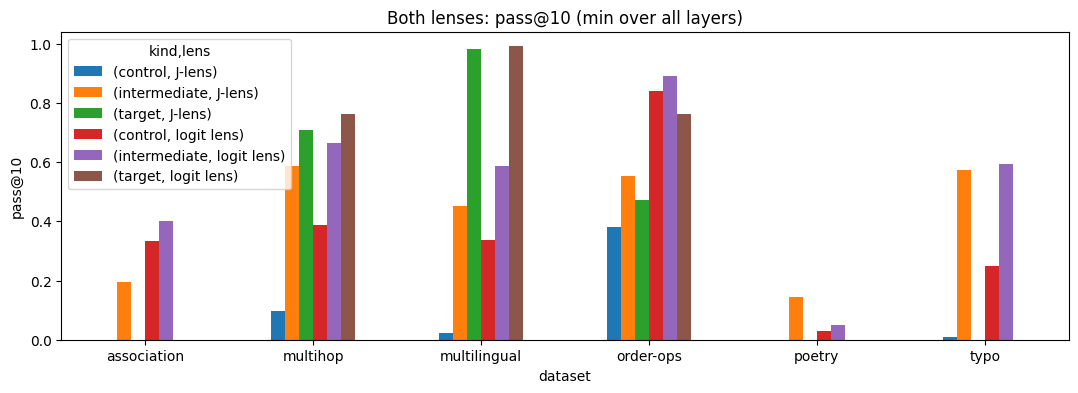

"J-lens − logit lens, inner pass@k",intermediate,control,target
dataset,,,
association,-0.206,-0.333,NaN
multihop,-0.079,-0.299,-0.161
multilingual,-0.133,-0.315,-0.009
order-ops,-0.400,-0.490,-0.364
poetry,0.092,-0.031,NaN
typo,-0.021,-0.240,NaN


In [47]:
at_k = scores[scores.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
at_k.plot.bar(figsize=(13, 4), rot=0, title=f"Both lenses: pass@{K} (min over all layers)")
plt.ylabel(f"pass@{K}")
plt.show()

inner_at_k = inner[inner.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
output_at_k = output[output.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
inner_delta = pd.DataFrame({
    kind: inner_at_k[(kind, "J-lens")] - inner_at_k[(kind, "logit lens")]
    for kind in ("intermediate", "control", "target")
    if all((kind, name) in inner_at_k.columns for name in LENS_NAMES)
})
display(inner_delta.rename_axis(columns="J-lens − logit lens, inner pass@k").round(3))

## 4. At what depth do the words surface?

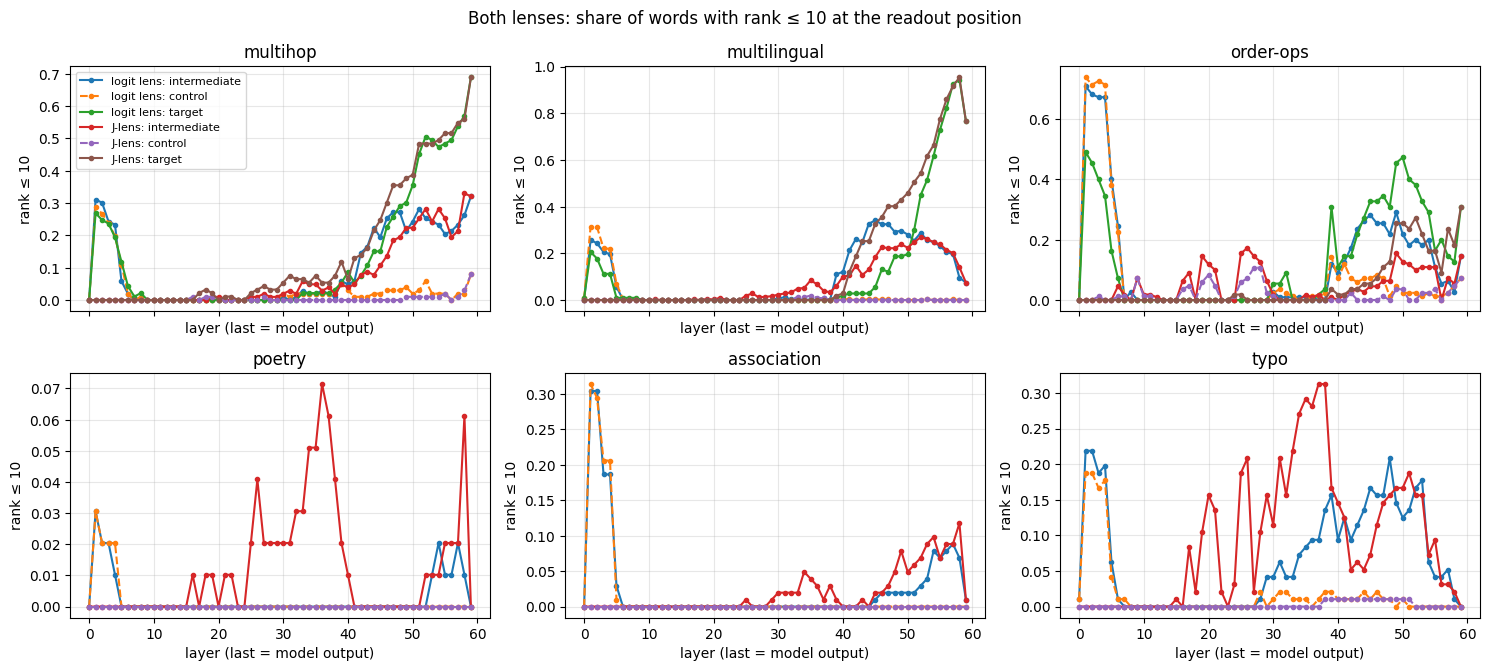

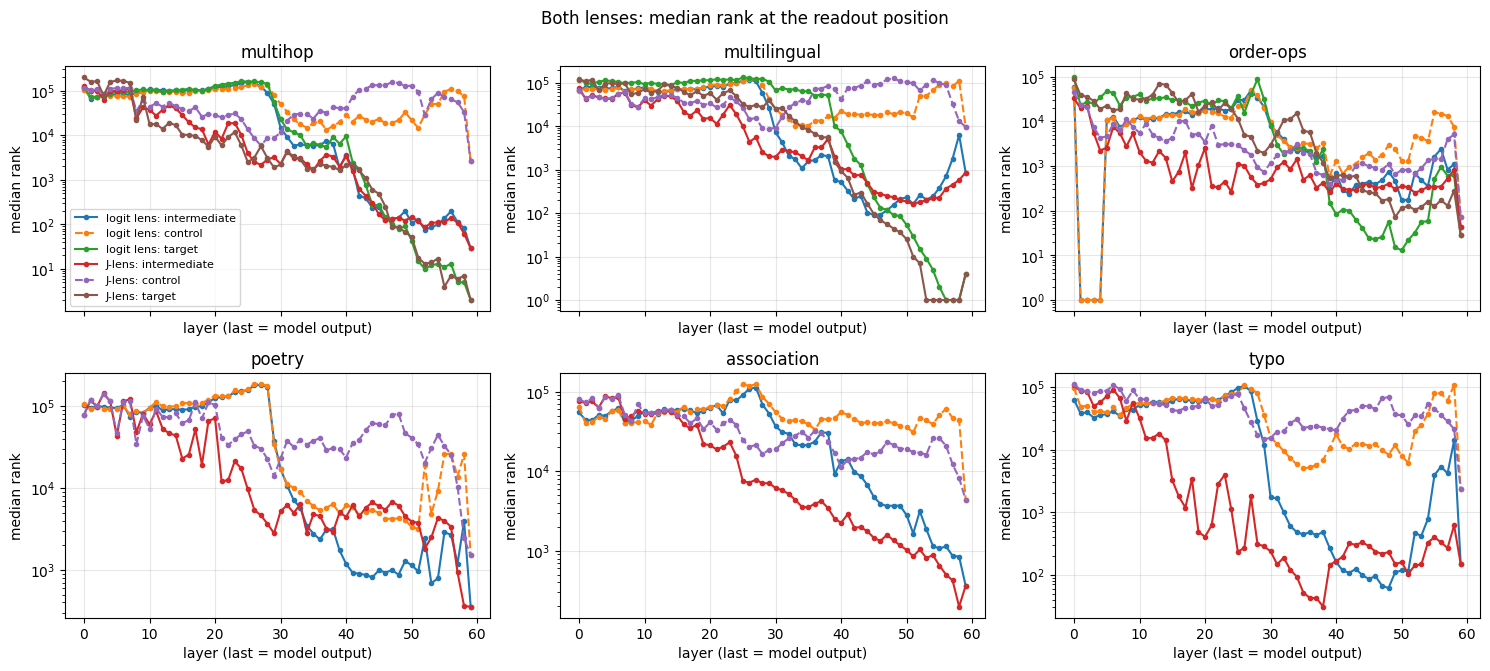

In [48]:
def word_curves(stat):
    return {
        f"{name}: {kind}": stat(words[(words.lens == name) & (words.kind == kind)])
        for name in LENS_NAMES
        for kind in ("intermediate", "control", "target")
    }


plot_layer_curves(
    word_curves(lambda frame: layer_hit_rate(frame, K)),
    title=f"Both lenses: share of words with rank ≤ {K} at the readout position",
    ylabel=f"rank ≤ {K}",
)
plot_layer_curves(
    word_curves(layer_median_rank),
    title="Both lenses: median rank at the readout position",
    ylabel="median rank",
    logy=True,
)

Where the best rank of each intermediate is reached (only words that are hits, rank ≤ K):

In [49]:
(
    inter[inter.best_rank <= K]
    .groupby(["dataset", "lens"]).best_layer.value_counts().unstack(fill_value=0)
    .reindex(columns=range(model.n_layers), fill_value=0)
)

best_layer               0    1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  \
dataset      lens                                                                                                                                                                                                                              
association  J-lens       0    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   1   0   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   2   0   
             logit lens   0   31   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   1   
multihop     J-lens       0    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   1   1   0   0   2   0   0   0   0   1   1   1   0   5   1   0   1   2   5   3   3   5   5   
             logit lens   0   32   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   2   5   4   0   5   0   2   0   0   2   3   
multilingual J-lens       0    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   2   5   0   0   1   0   0   1   6   2   6   2   1   1   8  15   7   8   4   3  12  19  10  15   7   5  15  21   
             logit lens   0  110   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   6  11  26  19   3  17  18  10   1   4   2   2   4  13   
order-ops    J-lens       0    0   0   0   0   0   3   0   0   6   0   2   0   0   0   0   1   0   0   2   6   2   0   0   0   1   0   5   3   0   0   0   0   0   0   0   0   0   0   0   0   1   1   1   0   0   0   1   1  11   0   2   1   
             logit lens   0   78   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   2   0   0   0   3   2   3   1   2   0   5   0   0   0   
poetry       J-lens       0    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0   0   0   0   0   1   2   0   2   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
             logit lens   0    3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
typo         J-lens       0    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   2   0   4   3   3   0   0   0   1   1   0   1   0   0   1   0   0   1   6   5   4   2   0   5   1   0   0   0   0   0   1   0   2   4   3   3   
             logit lens   1   21   0   2   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0   0   0   0   0   0   1   5   0   1   1   1   1   1   0   1   3   1   1   1   5   

best_layer               53  54  55  56  57  58  59  
dataset      lens                                    
association  J-lens       2   0   0   3   2   5   0  
             logit lens   0   1   2   1   3   0   0  
multihop     J-lens       1   2   0   0   2   5   7  
             logit lens   0   1   1   0   1   0   8  
multilingual J-lens       3   5   3   1   3   2   0  
             logit lens   1   1   0   1   0   0   0  
order-ops    J-lens       0   1   0   0   1   0   9  
             logit lens   0   0   0   0   2   0   0  
poetry       J-lens       0   1   0   0   0   3   0  
             logit lens   0   0   0   0   1  

## 5. How both lenses behave in general

Over all prompt positions (not only the readout one):

* **agreement** — the layer's top-1 equals the model's top-1: how deep the final prediction is formed;
* **copy rate** — the layer's top-1 is the input token at that position: the residual stream still "is" the token embedding
  (models with tied embeddings share the input and output token weights, so an untouched embedding decodes to itself);
* **KL(model ‖ layer)** — how far the layer's distribution is from the output one.

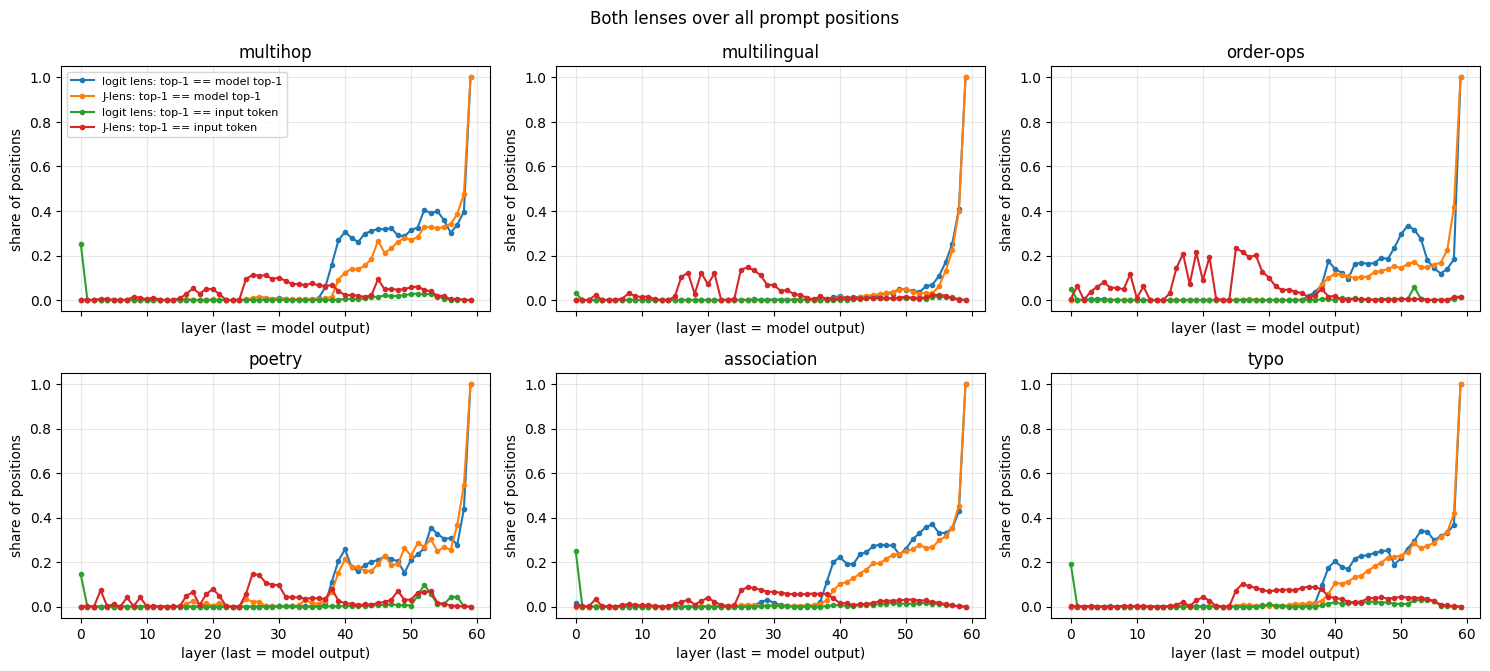

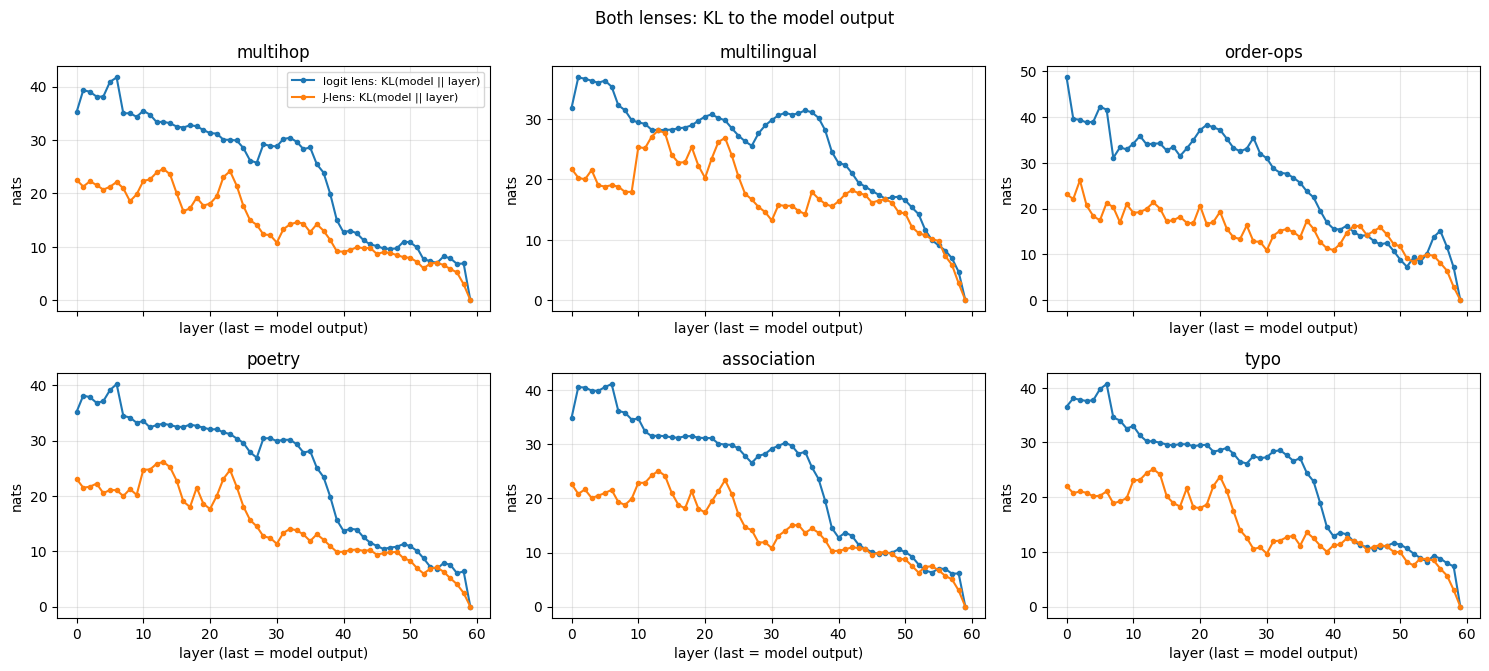

In [50]:
behaviour = {
    name: {column: layer_mean(items[items.lens == name], column)
           for column in ("agreement", "copy_rate", "kl_to_final")}
    for name in LENS_NAMES
}
plot_layer_curves(
    {f"{name}: top-1 == model top-1": behaviour[name]["agreement"] for name in LENS_NAMES}
    | {f"{name}: top-1 == input token": behaviour[name]["copy_rate"] for name in LENS_NAMES},
    title="Both lenses over all prompt positions",
    ylabel="share of positions",
)
plot_layer_curves(
    {f"{name}: KL(model || layer)": behaviour[name]["kl_to_final"] for name in LENS_NAMES},
    title="Both lenses: KL to the model output",
    ylabel="nats",
)

In [51]:
behaviour_rows = []
for name in LENS_NAMES:
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    for dataset in agreement.index:
        behaviour_rows.append({
            "dataset": dataset,
            "lens": name,
            "agreement ≥ 50% from": first_layer(agreement.loc[dataset], 0.5),
            "KL ≤ 1 nat from": first_layer(kl.loc[dataset], 1.0, above=False),
            "copy rate at L0": copy_rate.loc[dataset, 0],
            f"copy rate at L{LAST - 1}": copy_rate.loc[dataset, LAST - 1],
        })
pd.DataFrame(behaviour_rows).set_index(["dataset", "lens"]).unstack("lens").round(3)

agreement ≥ 50% from            KL ≤ 1 nat from            copy rate at L0            copy rate at L58           
lens                       J-lens logit lens          J-lens logit lens          J-lens logit lens           J-lens logit lens
dataset                                                                                                                       
association                    59         59              59         59           0.003      0.249            0.001      0.001
multihop                       59         59              59         59           0.001      0.254            0.000      0.001
multilingual                   59         59              59         59           0.001      0.032            0.001      0.003
order-ops                      59         59              59         59           0.005      0.051            0.014      0.004
poetry                         58         59              59         59           0.000      0.144            0.000      0.001
typo                           59         59              59         59           0.001      0.191            0.001      0.000

## 6. What drives a hit

### 6a. The word is already in the prompt

Early layers of the logit lens can decode the input token itself, so a word that is literally in the prompt
(e.g. a number in order-ops) can be a "hit" without any computation.

In [52]:
hits = inter.assign(hit=inter.best_rank <= K, inner_hit=inter.inner_best <= K)
hits.groupby(["dataset", "in_prompt", "lens"]).hit.agg(["mean", "size"]).unstack(["in_prompt", "lens"]).round(3)

mean                                size                             
in_prompt     False             True              False             True            
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.196      0.402    NaN        NaN  102.0      102.0    NaN        NaN
multihop      0.539      0.647  0.000        0.0  102.0      102.0    1.0        1.0
multilingual  0.449      0.584  1.000        1.0  425.0      425.0    3.0        3.0
order-ops     0.448      0.793  0.673        1.0   58.0       58.0   52.0       52.0
poetry        0.143      0.051    NaN        NaN   98.0       98.0    NaN        NaN
typo          0.573      0.594    NaN        NaN   96.0       96.0    NaN        NaN

### 6b. Single-token words vs words that only have a first-token fallback

In [53]:
hits.groupby(["dataset", "single_token", "lens"]).hit.agg(["mean", "size"]).unstack(["single_token", "lens"]).round(3)

mean                                size                             
single_token  True              False             True              False           
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.196      0.402    NaN        NaN  102.0      102.0    NaN        NaN
multihop      0.564      0.681  0.222      0.222   94.0       94.0    9.0        9.0
multilingual  0.453      0.586    NaN        NaN  428.0      428.0    NaN        NaN
order-ops     0.550      0.890  1.000      1.000  109.0      109.0    1.0        1.0
poetry        0.143      0.051    NaN        NaN   98.0       98.0    NaN        NaN
typo          0.573      0.594    NaN        NaN   96.0       96.0    NaN        NaN

### 6c. Role of the intermediate

multilingual: `[language, relation, source word, answer in English]`; order-ops: `[intermediate number, operation]`.

In [54]:
roles = hits[hits.dataset.isin(list(ROLE_NAMES))].copy()
roles["role_name"] = [ROLE_NAMES[d][r] for d, r in zip(roles.dataset, roles.role)]
roles.groupby(["dataset", "role_name", "lens"]).agg(
    hit_rate=("hit", "mean"), median_best_rank=("best_rank", "median"), n=("hit", "size"),
    inner_hit_rate=("inner_hit", "mean"), median_inner_rank=("inner_best", "median"),
).unstack("lens").round(3)

hit_rate            median_best_rank                 n            inner_hit_rate            median_inner_rank           
lens                               J-lens logit lens           J-lens logit lens J-lens logit lens         J-lens logit lens            J-lens logit lens
dataset      role_name                                                                                                                                   
multilingual answer (English)       0.944      1.000              1.0        1.0    107        107          0.944      1.000               1.0        1.0
             language               0.028      0.112            406.0     3045.0    107        107          0.028      0.112             424.0     6278.0
             relation               0.449      0.636             12.0        3.0    107        107          0.449      0.636              12.0        3.0
             source word            0.393      0.598             24.0        2.0    107        107          0.393      0.598              24.0        2.0
order-ops    intermediate number    0.418      0.836             13.0        1.0     55         55          0.364      0.836              23.0        1.0
             operation              0.691      0.945              7.0        1.0     55         55          0.618      0.945               7.0        1.0

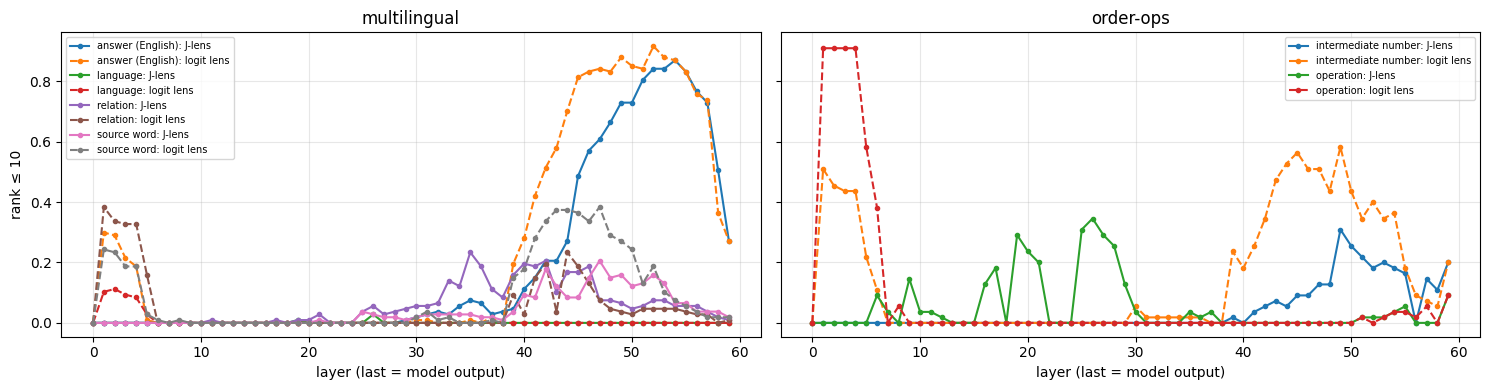

In [55]:
fig, axes = plt.subplots(1, len(ROLE_NAMES), figsize=(15, 4), sharey=True, squeeze=False)
for ax, dataset in zip(axes.flat, ROLE_NAMES):
    group = roles[roles.dataset == dataset]
    for (role, name), role_group in group.groupby(["role_name", "lens"]):
        ax.plot(
            (np.stack(role_group.ranks) <= K).mean(0), marker="o", ms=3,
            label=f"{role}: {name}", linestyle="--" if name == "logit lens" else "-",
        )
    ax.set_title(dataset)
    ax.set_xlabel("layer (last = model output)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
axes.flat[0].set_ylabel(f"rank ≤ {K}")
plt.tight_layout()
plt.show()

### 6d. Does the intermediate show up more often when the model gets the answer right?

In [56]:
correctness = hits.merge(
    with_target[["dataset", "item", "model_correct"]], on=["dataset", "item"], validate="many_to_one"
)
correctness.groupby(["dataset", "model_correct", "lens"]).hit.agg(["mean", "size"]).unstack(["model_correct", "lens"]).round(3)

mean                                size                             
model_correct  False             True              False             True            
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                              
multihop       0.524      0.635  0.550      0.650     63         63     40         40
multilingual   0.463      0.632  0.436      0.506    272        272    156        156
order-ops      0.548      0.855  0.562      0.938     62         62     48         48

## 7. Items: successes and failures

In [57]:
columns = ["dataset", "item", "lens", "word", "best_rank", "best_layer", "inner_best", "inner_best_layer", "in_prompt"]
inter.sort_values("best_rank").groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
1460,multilingual,slovak-opposite-young,J-lens,old,1,51,1,51,False
1413,multilingual,serbian-opposite-day,logit lens,opposite,1,1,1,1,False
1415,multilingual,serbian-opposite-day,logit lens,night,1,45,1,45,False
1424,multilingual,serbian-opposite-day,J-lens,night,1,45,1,45,False
1430,multilingual,croatian-opposite-big,logit lens,Croatian,1,1,1,1,False
1442,multilingual,croatian-opposite-big,J-lens,small,1,48,1,48,False
3834,typo,typo-something,logit lens,something,1,4,1,4,False
3802,typo,typo-language,logit lens,language,1,1,1,1,False
3804,typo,typo-language,J-lens,language,1,40,1,40,False
3808,typo,typo-government,J-lens,government,1,19,1,19,False


In [58]:
inter.sort_values("best_rank", ascending=False).groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
2074,multilingual,es-time-after-day,logit lens,español,34229,29,34229,29,False
2432,multilingual,es-order-first-last,logit lens,español,31969,28,31969,28,False
2306,multilingual,pt-place-near-far,logit lens,português,29861,28,29861,28,False
3162,poetry,couplet-cake-mistake,logit lens,mistake,24477,58,24477,58,False
3518,association,frustrated,logit lens,frustrated,11997,52,11997,52,False
2442,multilingual,es-order-first-last,J-lens,order,10104,14,10104,14,False
3134,poetry,couplet-time-climb,logit lens,climb,10003,53,10003,53,False
2424,multilingual,de-order-first-last,J-lens,order,8123,59,9990,14,False
1511,multilingual,persian-color-blood,J-lens,Persian,7226,52,7226,52,False
3414,association,fired,logit lens,fired,6297,31,6297,31,False


What the lens reads at the readout position, layer by layer (first items of each dataset):

In [59]:
readout = items.groupby(["dataset", "lens"]).head(2).set_index(["dataset", "item", "lens"]).readout_top1.apply(pd.Series)
readout.columns.name = "layer"
readout.sort_index()[shown_layers(model.n_layers, LAYER_STRIDE)]

layer                                                 0           5           10        15           20           25          30           35              40              45           50           55           59
dataset      item                 lens                                                                                                                                                                              
association  grief                J-lens            Rong        ROSS          No        No           No           \n   something   stubbornly               她              她的            她          her         \n\n
                                  logit lens        \n\n  <unused21>          не         в           не           По        when         that            When            When            她            她         \n\n
             pregnant             J-lens            Rong        ROSS          No        No           .“           \n         <b>      herself               她              그녀            她       \n\n\n         \n\n
                                  logit lens       </h5>  <unused21>          не         в           не          как        When         That            When            When         When       \n\n\n         \n\n
multihop     amazon-language      J-lens          Марина        ROSS          No        No           ,…        <eos>    <strong>     ilingual              英语              英语    Brazilian      Spanish   Portuguese
                                  logit lens          im  <unused36>          ла   க்ஸாண்ட          เรา            醿          is         that   predominantly   predominantly   Portuguese   Portuguese   Portuguese
             carnival-ocean       J-lens             เอก        ROSS          No        No        ocean        ocean       ocean        ocean              ……       Caribbean    Caribbean        ocean    Caribbean
                                  logit lens         the  </caption>           ي         ي           왔다           왔다        that         that            most            same     Atlantic     Atlantic    Caribbean
multilingual french-season-summer J-lens              No        ROSS          .﻿        No         \n\n         \...      summer     seasonal         busiest          season       idéale     occasion      automne
                                  logit lens   <unused7>  <unused34>          se        ла           ла           ла         For          For             one             one          one     occasion      automne
             spanish-opposite-big J-lens             Вин        ROSS          No        No            "         ..."          ."           ."        ________             nhỏ          nhỏ        small           pe
                                  logit lens  <unused53>       <bos>      immers    immers     Antennes   coalgebras          in            c        ________           small        small        small           pe
order-ops    parens-add-mult      J-lens            ROSS          No          No        No            헤            =          (=           (=            ...?            ...?         ...?         ...?             
                                  logit lens        ด้วย  <unused53>          ad        iz           iz           จะ       which        which               ？            ...?         what          ..?             
             parens-sub-mult      J-lens         centrif           =          No        No       Cesare            =           =            =            ...?             __.      fifteen      fifteen             
                                  logit lens  rhinoceros  <unused53>          le        iz           iz          Что        that         that                         fifteen      fifteen           ۱۵             
poetry       couplet-breath-death J-lens              No          No          No        No         ROSS    murderous   murderous        death           while         

The most common readout top-1 tokens per layer over all items — generic tokens mean the lens shows no item-specific content there:

In [60]:
top1_tables = {}
for name in LENS_NAMES:
    top1_by_layer = pd.DataFrame(items[items.lens == name].readout_top1.tolist())
    top1_tables[name] = pd.DataFrame({
        "distinct top-1 / items": top1_by_layer.nunique() / len(top1_by_layer),
        "most common": {
            layer: ", ".join(f"{token!r}×{count}" for token, count in column.value_counts().head(5).items())
            for layer, column in top1_by_layer.items()
        },
    }).rename_axis("layer")
pd.concat(top1_tables, axis=1, names=["lens", "metric"])

lens               logit lens                                                                    J-lens                                                   
metric distinct top-1 / items                                        most common distinct top-1 / items                                        most common
layer                                                                                                                                                     
0                    0.254083  '<unused71>'×96, '\n\n'×62, ' is'×41, '<unused...               0.101633  ' No'×174, 'ROSS'×139, ' Rong'×125, '</i>'×13,...
1                    0.085299  '<bos>'×103, '<unused81>'×98, '<unused23>'×60,...               0.085299  'ROSS'×325, ' Rong'×119, ' ='×32, 'جاتا'×9, ' ...
2                    0.081670  '<bos>'×102, '<unused81>'×98, '<unused20>'×72,...               0.021779  'ROSS'×438, ' Rong'×103, 'loose'×1, ' ROS'×1, ...
3                    0.078040  '<bos>'×132, '<unused21>'×102, '<unused81>'×98...               0.123412  ' No'×117, ' Rong'×83, 'JAM'×67, 'ROSS'×56, ' ...
4                    0.087114  '<bos>'×144, '<unused81>'×98, '<unused21>'×95,...               0.085299  'ROSS'×362, ' No'×58, ' Rong'×43, ' ROS'×20, '...
5                    0.105263  '</h2>'×97, '<bos>'×94, '<unused21>'×88, '<unu...               0.054446  'ROSS'×318, ' “'×78, ' No'×58, ' Rong'×47, ' =...
6                    0.094374  ' für'×79, 'ic'×72, '<unused53>'×56, '<bos>'×5...               0.041742  'ROSS'×418, ' Rong'×58, ' Akira'×27, ' _______...
7                    0.157895  '<unused0>'×90, ' la'×65, 'le'×58, 'end'×39, '...               0.081670  ' Rong'×232, 'ROSS'×79, ' No'×47, '*"'×37, ' ≠...
8                    0.186933  '<unused0>'×103, ' в'×44, '</h2>'×37, '</capti...               0.161525  ' No'×249, ' Rong'×46, ' "'×31, '..."'×19, ' s...
9                    0.217786    ' в'×48, 'im'×43, '�'×36, ' не'×33, ' nicht'×29               0.119782  'ROSS'×200, '..."'×48, ' ='×29, ' Rong'×25, ' ...
10                   0.234120   ' nicht'×61, ' не'×59, 'ch'×42, 'ad'×40, 'qu'×22               0.079855    ' No'×471, ' *'×6, ' "'×5, ' .*'×4, ' whence'×4
11                   0.235935  ' не'×82, ' nicht'×73, 'ina'×47, 'ad'×39, 'ch'×24               0.112523   ' No'×352, ' *'×35, ' Akira'×14, '.*'×11, ' "'×9
12                   0.206897     ' в'×68, '�'×52, ' nicht'×51, 'ch'×37, 'ad'×36               0.050817  ' No'×486, ' *'×14, ' intér'×9, ' —'×4, ' engg...
13                   0.223230     ' в'×77, ' nicht'×51, '�'×47, 'ch'×38, 'le'×36               0.029038  ' No'×528, ' بی\u200c'×3, 'ㆍ'×3, ' beneath'×2,...
14                   0.235935     ' в'×79, ' nicht'×46, 'ch'×41, '�'×38, 'le'×27               0.058076  ' No'×488, ' enggak'×7, ' intér'×6, ' —'×5, ',...
15                   0.246824  ' в'×52, ' nicht'×50, 'iz'×39, 'ina'×27, ' не'×25               0.061706  ' No'×485, '</em>'×11, ' �'×6, ' "'×6, '\uf0be'×3
16                   0.272232  ' в'×57, 'iz'×55, ' nicht'×49, ' Antennes'×36,...               0.141561   ' No'×278, ' "'×67, '\n'×42, ' ='×23, '</em>'×19
17                   0.263158   'iz'×60, ' в'×36, '一些'×32, ' не'×20, ' nicht'×18               0.141561    ' No'×205, ' "'×79, '\n'×61, ' ='×41, 'ROSS'×33
18                   0.292196  'iz'×61, '一些'×37, ' в'×36, ' Antennes'×31, ' н...               0.108893     ' No'×429, '—“'×16, ' "'×12, ' �'×6, '</em>'×5
19                   0.288566  ' Antennes'×72, 'iz'×60, '一些'×41, ' По'×35, ' ...               0.190563    ' No'×176, ' "'×71, '\n'×50, ' ='×46, 'ROSS'×46
20                   0.281307  ' Antennes'×77, 'iz'×45, ' По'×43, '一些'×37, ' ...               0.243194  'ROSS'×78, ' "'×61, '\n'×31, ' No'×25, 'minste...
21                   0.270417  ' Antennes'×75, ' По'×43, '一些'×41, 'iz'×41, ' ...               0.134301   ' No'×290, ' "'×67, '\n'×36, ' ='×34, '</em>'×20
22                   0.259528  ' Antennes'×71, ' не'×60, '一些'×41, 'เรา'×27, '...               0.014519    ' No'×536, '\n'×7,

### 7a. Paired inner-layer ranks: which lens improves each intermediate?

One row per intermediate occurrence, aligned by dataset, item, word, and role. A positive
`log10 gain` means J-lens lowers the best inner-layer rank; ties are counted explicitly.

In [61]:
head_to_head = inter.pivot(
    index=["dataset", "item", "word", "role"], columns="lens", values="inner_best"
)
head_to_head["winner"] = np.select(
    [head_to_head["J-lens"] < head_to_head["logit lens"],
     head_to_head["J-lens"] > head_to_head["logit lens"]],
    ["J-lens", "logit lens"], default="tie",
)
head_to_head["log10 gain"] = np.log10(head_to_head["logit lens"]) - np.log10(head_to_head["J-lens"])
paired_summary = head_to_head.groupby("dataset").winner.value_counts().unstack(fill_value=0)
paired_summary = paired_summary.reindex(columns=["J-lens", "logit lens", "tie"], fill_value=0)
paired_summary["median log10 gain"] = head_to_head.groupby("dataset")["log10 gain"].median()
display(paired_summary.round(3))
display(head_to_head.sort_values("log10 gain", ascending=False).head(15))
display(head_to_head.sort_values("log10 gain").head(15))

winner,J-lens,logit lens,tie,median log10 gain
dataset,,,,
association,46,51,5,-0.024
multihop,28,50,25,0.000
multilingual,149,158,121,0.000
order-ops,11,81,18,-0.845
poetry,56,42,0,0.107
typo,38,46,12,0.000


lens                                            J-lens  logit lens  winner  log10 gain
dataset      item                 word    role                                        
multilingual french-season-summer French  0          6       26798  J-lens    3.649951
             de-time-old-new      German  0         10       14905  J-lens    3.173332
             es-order-first-last  español 0         30       31969  J-lens    3.027608
             spanish-opposite-big Spanish 0         22       19430  J-lens    2.946050
             de-place-near-far    German  0         18       15153  J-lens    2.925226
             es-place-near-far    español 0         26       20962  J-lens    2.906459
             de-order-first-last  German  0         10        7363  J-lens    2.867055
             de-size-big-small    German  0         20       12821  J-lens    2.806892
             de-place-up-down     German  0         26       16047  J-lens    2.790421
             es-place-up-down     español 0         26       14053  J-lens    2.732796
             dutch-direction-left Dutch   0        134       59721  J-lens    2.649022
             es-size-big-small    español 0         17        4786  J-lens    2.449524
             de-color-night       German  0         81       22024  J-lens    2.434411
typo         typo-house           house   0          1         247  J-lens    2.392697
             typo-village         village 0          1         227  J-lens    2.356026

lens                                                J-lens  logit lens      winner  log10 gain
dataset      item                   word      role                                            
multilingual es-order-first-last    order     1      10104           1  logit lens   -4.004493
             de-order-first-last    order     1       9990           1  logit lens   -3.999565
             pt-order-first-last    order     1       9396           1  logit lens   -3.972943
             fr-order-first-last    order     1       5567           1  logit lens   -3.745621
             ukrainian-opposite-day Ukrainian 0       3616           1  logit lens   -3.558228
poetry       couplet-cat-mat        mat       0       3366           1  logit lens   -3.527114
multilingual swedish-opposite-hard  Swedish   0       3348           1  logit lens   -3.524785
multihop     nhop-insect-element    six       1       3262           1  logit lens   -3.513484
poetry       couplet-mistake-make   make      0       3214           1  logit lens   -3.507046
multilingual pt-place-up-down       place     1       2859           1  logit lens   -3.456214
multihop     nhop-cube-element      six       1       2663           1  logit lens   -3.425371
             nhop-volleyball-planet six       1       2585           1  logit lens   -3.412461
             nhop-guitar-planet     six       1       2335           1  logit lens   -3.368287
multilingual slovak-opposite-young  Slovak    0       2277           1  logit lens   -3.357363
             hungarian-color-sea    Hungarian 0       1935           1  logit lens   -3.286681

## 8. Adaptations of reference Figures 52, 55, and 56

These reproduce **plot forms, not the reference experiment**: the loaded generic model/J-lens
and local evaluation sets are not the reference model or necessarily its sample subsets.
The original exact sample subsets and symmetric-KL normalization are unknown. There is
**no tuned lens** and no Sonnet workspace shading. See `docs/reference_plots.md` and
`docs/lens_metrics.md` for shared definitions and limitations.

### 8a. Figure 52: intermediate hit rate versus k (no new inference)
Only annotated **single-token intermediates** are included; first-token fallbacks are excluded.
For each k, take each word's best rank over **all blocks, including the shared final output**,
average word hits within an item, then average items. Items with no retained words are omitted,
not failures. Counts disclose exclusions **per lens** (paired annotations are repeated).
Tokenization/accepted spelling variants are this evaluator's, not a guaranteed reference match.
Cached ranks inherit `evaluate_paired()`'s `prompt.rstrip()` before tokenization: trailing
whitespace is removed, potentially changing tokenization and the final-token readout position.
This is not a whitespace-exact reproduction; established evaluation semantics are unchanged.

Legends report trapezoidal AUC versus **log(k)** normalized by log(100/1), on k = 1, 2, 5, 10,
20, 50, 100. AUC/hit rates range from 0 to 1. Black = J-lens; red = logit lens.

,dataset,lens,n_words_total,n_words_used,n_words_excluded,n_items_total,n_items_used,n_items_excluded
0,association,J-lens,102,102,0,102,102,0
1,association,logit lens,102,102,0,102,102,0
2,multihop,J-lens,103,94,9,93,84,9
3,multihop,logit lens,103,94,9,93,84,9
4,multilingual,J-lens,428,428,0,107,107,0
5,multilingual,logit lens,428,428,0,107,107,0
6,order-ops,J-lens,110,109,1,55,55,0
7,order-ops,logit lens,110,109,1,55,55,0
8,poetry,J-lens,98,98,0,98,98,0
9,poetry,logit lens,98,98,0,98,98,0


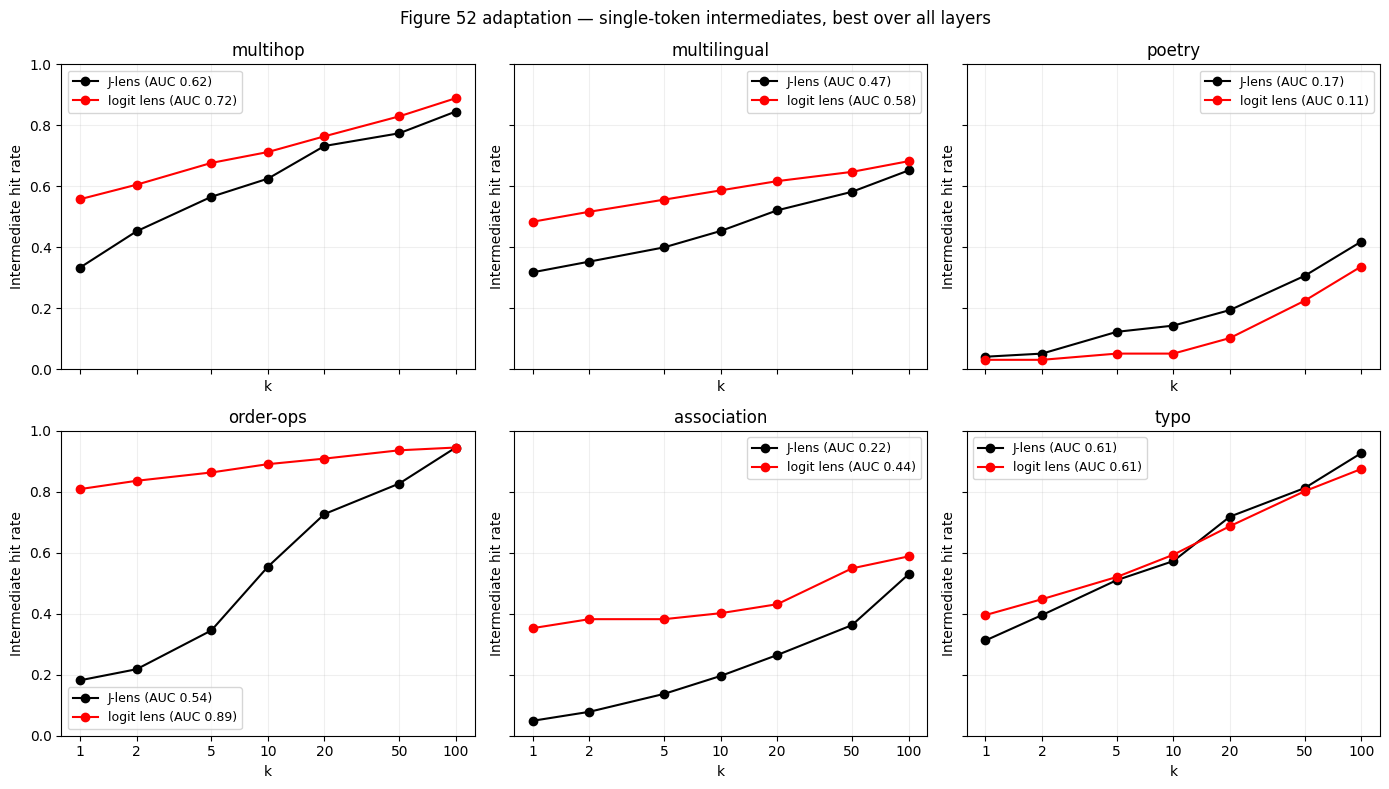

In [62]:
from jlens.reference_plots import (
    intermediate_rank_sweep, plot_intermediate_sweep,
    plot_distribution_summary, plot_lens_comparison,
)

reference52 = intermediate_rank_sweep(words)
display(reference52.counts)
fig52, axes52 = plot_intermediate_sweep(reference52)
plt.show()

### 8b. Figures 55/56: explicitly supplied held-out text (opt-in extra evaluation)
**No refit is needed.** These distribution metrics cannot be recovered from `words`/`items`;
they require new forwards with the already loaded model/lens. Default is **disabled**. Supply
independent texts below (not the fitting corpus or task prompts) and name their source.
No downloads or automatic corpus substitution occur. Small samples are diagnostics, not
reproductions of pretraining-distribution results. Record selection and fitting provenance.

All actual model blocks are evaluated. Depth = 100 * block_index / (n_blocks - 1): first
block output 0, shared final output 100; no embedding row. Means weight every non-special
input position equally, including each text's last position, after per-text truncation.
Longer texts contribute more tokens. Natural-log KL and entropy are in **nats**.

* **55:** KL(model || lens), lens entropy, top-1 agreement with model **in percent**.
  J-lens blue, logit lens purple.
* **56:** one purple J/logit comparison at each **same layer**: vocabulary-vector cosine,
  **0.5 * (KL(J || logit) + KL(logit || J))**, and top-1 agreement **as a fraction**.
  The half-sum is explicit; original normalization unknown. Cross-layer pairs are never averaged.
* Cosine compares corresponding rows of W_U and W_U @ J, averaged equally over nonzero
  vocabulary-vector pairs. This **linear-head-only geometry** excludes bias, final normalization,
  and softcap; it is not exact global geometry for a nonlinear decoder. Unsupported output
  heads/adapters are labeled **unavailable, not zero** in the status/counts table. Distributions
  still use `model.unembed`, including its normalization, output head, and any softcap.
  The cosine axis is **0 to 1** for nonnegative/unavailable values; any displayed negative value
  extends it to **-1 to 1**, disclosed in the title. Negative cosines are never silently clipped.

Start with a few short texts: all-layer readouts may be expensive for large models/vocabularies.
Position chunks bound vocabulary-distribution memory, not activation/Jacobian memory. Reduce
chunk size or sequence length if needed. Evaluation and plotting are separate so cached tables
can be replotted without extra forwards.

In [63]:
# Opt in here; keep this sample independent of lens fitting.
HELD_OUT_TEXTS = None  # a nonempty list[str] of held-out passages
HELD_OUT_SOURCE = ''  # corpus/version, split, sample selection
# Local-file example: one independently held-out passage per nonempty line.
# HELD_OUT_TEXTS = [s for s in Path('/path/to/heldout.txt').read_text().splitlines() if s.strip()]
# HELD_OUT_SOURCE = 'my-corpus v1, held-out split, first 8 passages (disjoint from fitting)'
HELD_OUT_MAX_SEQ_LEN = 128
HELD_OUT_POSITION_CHUNK_SIZE = 4
GEOMETRY_VOCAB_CHUNK_SIZE = 1024

In [64]:
# Clear cached results first so disabled/failed reruns cannot plot stale metrics.
held_out_metrics = held_out_geometry = held_out_run = None
if HELD_OUT_TEXTS is None:
    print('Figures 55/56 skipped: supply independent HELD_OUT_TEXTS and HELD_OUT_SOURCE above. No downloads or extra evaluation run.')
else:
    if not isinstance(HELD_OUT_TEXTS, (list, tuple)) or not HELD_OUT_TEXTS:
        raise ValueError('Supply a nonempty list/tuple of independently held-out strings.')
    if not all(isinstance(text, str) and text.strip() for text in HELD_OUT_TEXTS):
        raise ValueError('Every held-out passage must be a nonempty string.')
    if not isinstance(HELD_OUT_SOURCE, str) or not HELD_OUT_SOURCE.strip():
        raise ValueError('Describe the independent sample in HELD_OUT_SOURCE first.')
    from jlens.metrics import evaluate_distributions, lens_vector_geometry

    held_out_run = {
        'model': globals().get('MODEL_ID', type(model).__name__),
        'model_dtype': str(next(model.layers[0].parameters()).dtype),
        'device': str(model.input_device),
        'source': HELD_OUT_SOURCE, 'n_texts_supplied': len(HELD_OUT_TEXTS),
        'max_seq_len': HELD_OUT_MAX_SEQ_LEN,
        'position_chunk_size': HELD_OUT_POSITION_CHUNK_SIZE,
        'layers': 'all blocks, shared final output', 'weighting': 'token',
        'float32_matmul_precision': torch.get_float32_matmul_precision(),
    }
    display(held_out_run)
    held_out_metrics = evaluate_distributions(
        model, fitted_lens, HELD_OUT_TEXTS, layers=None,
        max_seq_len=HELD_OUT_MAX_SEQ_LEN,
        position_chunk_size=HELD_OUT_POSITION_CHUNK_SIZE, pairwise=True,
    )
    held_out_geometry = lens_vector_geometry(
        model, fitted_lens, layers=None, vocab_chunk_size=GEOMETRY_VOCAB_CHUNK_SIZE,
    )
    display(held_out_metrics.layers)
    display(held_out_geometry)

Figures 55/56 skipped: supply independent HELD_OUT_TEXTS and HELD_OUT_SOURCE above. No downloads or extra evaluation run.


In [65]:
fig55 = axes55 = fig56 = axes56 = None
if held_out_metrics is None or held_out_geometry is None:
    print('No held-out figures to plot. Configure the sample and run the evaluation cell first.')
else:
    print('Held-out sample:', held_out_run['source'])
    fig55, axes55 = plot_distribution_summary(held_out_metrics.layers, n_layers=model.n_layers)
    plt.show()
    fig56, axes56 = plot_lens_comparison(
        held_out_metrics.pairs, held_out_geometry, n_layers=model.n_layers,
    )
    plt.show()

No held-out figures to plot. Configure the sample and run the evaluation cell first.


## 9. Conclusions

The cell below turns the numbers above into statements, so they stay correct after a re-run
(other seed, other `K`, other model size).

In [66]:
def pct(x):
    return "n/a" if x is None or pd.isna(x) else f"{100 * x:.0f}%"


def layer(x):
    return "never" if x is None else f"L{x}"


def hit_rates(frame, column):
    """Hit rate (best rank <= K) split by a boolean column: {value: (rate, n)}."""
    hit = (frame.best_rank <= K).groupby(frame[column])
    return {value: (rate, n) for value, rate, n in zip(hit.mean().index, hit.mean(), hit.size())}

In [67]:
lines = ['Target metrics are conditional on complete single-token coverage; unsupported targets are excluded.']
for dataset, row in answer_coverage.iterrows():
    lines.append(f'{dataset}: target coverage {int(row.scored)}/{int(row.total)} ({pct(row.coverage)}), '
                 f'unsupported {int(row.unsupported)}; model top-1 accuracy {pct(accuracy.get(dataset))}.')
for name in LENS_NAMES:
    lines.append(f"--- {name} ---")
    lens_at_k = at_k.xs(name, axis=1, level="lens")
    inner_lens_at_k = inner_at_k.xs(name, axis=1, level="lens")
    output_lens_at_k = output_at_k.xs(name, axis=1, level="lens")
    lens_inter = inter[inter.lens == name]
    inter_curve = layer_hit_rate(lens_inter, K)
    target_curve = layer_hit_rate(target[target.lens == name], K)
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    lens_roles = roles[roles.lens == name]
    lens_correctness = correctness[correctness.lens == name]
    for dataset in lens_at_k.index:
        i, c = lens_at_k.loc[dataset, "intermediate"], lens_at_k.loc[dataset].get("control")
        verdict = "clearly above" if i >= c + 0.1 else "slightly above" if i > c else "NOT above"
        peak = inter_curve.loc[dataset].iloc[:-1]
        lines.append(
            f"{dataset}: intermediates pass@{K} {pct(i)} vs control {pct(c)} — {verdict} chance; "
            f"inner layers alone {pct(inner_lens_at_k.loc[dataset, 'intermediate'])}, model output alone "
            f"{pct(output_lens_at_k.loc[dataset, 'intermediate'])}; best inner layer L{peak.idxmax()} "
            f"({pct(peak.max())} of words at rank ≤ {K})."
        )

    for dataset in target_curve.index:
        curve = target_curve.loc[dataset]
        if curve.iloc[-1] == 0:
            lines.append(f"{dataset}: the target is never in the output top-{K}.")
        else:
            lines.append(
                f"{dataset}: the target is in the lexical output top-{K} for {pct(curve.iloc[-1])} of scorable items "
                f"and reaches half of that by {layer(first_layer(curve, curve.iloc[-1] / 2))}."
            )

    for dataset in agreement.index:
        lines.append(
            f"{dataset}: lens top-1 == model top-1 on ≥50% of positions from {layer(first_layer(agreement.loc[dataset], 0.5))}, "
            f"KL ≤ 1 nat from {layer(first_layer(kl.loc[dataset], 1.0, above=False))}; copy rate "
            f"{pct(copy_rate.loc[dataset, 0])} at L0 → {pct(copy_rate.loc[dataset, LAST - 1])} at L{LAST - 1}."
        )

    for column, yes, no in [
        ("in_prompt", "already in the prompt", "absent from it"),
        ("single_token", "single-token", "first-token fallback"),
    ]:
        rates = hit_rates(lens_inter, column)
        (r_yes, n_yes), (r_no, n_no) = rates.get(True, (None, 0)), rates.get(False, (None, 0))
        lines.append(f"Intermediates {yes}: hit rate {pct(r_yes)} (n={n_yes}) vs {pct(r_no)} (n={n_no}) {no}.")

    for dataset, group in lens_roles.groupby("dataset"):
        by_role = group.groupby("role_name").hit.mean().sort_values(ascending=False)
        lines.append(f"{dataset} by role: " + ", ".join(f"{name} {pct(rate)}" for name, rate in by_role.items()) + ".")

    by_correct = lens_correctness.groupby("model_correct").hit.mean()
    lines.append(
        f"Intermediate hit rate when the model is right: {pct(by_correct.get(True))}, when wrong: {pct(by_correct.get(False))}."
    )


for dataset in inner_at_k.index:
    row = inner_at_k.loc[dataset]
    j, l = row[("intermediate", "J-lens")], row[("intermediate", "logit lens")]
    jc, lc = row[("control", "J-lens")], row[("control", "logit lens")]
    lines.append(
        f"{dataset}: inner-layer pass@{K}, J-lens {pct(j)} vs logit lens {pct(l)} "
        f"(Δ {100 * (j - l):+.1f} pp); margins over control "
        f"{100 * (j - jc):+.1f} pp vs {100 * (l - lc):+.1f} pp."
    )
for dataset, row in paired_summary.iterrows():
    lines.append(
        f"{dataset}: J-lens ranks intermediates higher in {row.get('J-lens', 0):.0f} cases, "
        f"logit lens in {row.get('logit lens', 0):.0f}, ties {row.get('tie', 0):.0f}; "
        f"median log10 rank gain {row['median log10 gain']:+.2f}."
    )
for line in lines:
    print("•", line)

• Model accuracy (top-1 == target): multihop 38%, multilingual 36%, order-ops 44%.
• --- logit lens ---
• association: intermediates pass@10 40% vs control 33% — slightly above chance; inner layers alone 40%, model output alone 1%; best inner layer L1 (30% of words at rank ≤ 10).
• multihop: intermediates pass@10 66% vs control 39% — clearly above chance; inner layers alone 63%, model output alone 35%; best inner layer L1 (31% of words at rank ≤ 10).
• multilingual: intermediates pass@10 59% vs control 34% — clearly above chance; inner layers alone 59%, model output alone 7%; best inner layer L45 (34% of words at rank ≤ 10).
• order-ops: intermediates pass@10 89% vs control 84% — slightly above chance; inner layers alone 89%, model output alone 15%; best inner layer L1 (71% of words at rank ≤ 10).
• poetry: intermediates pass@10 5% vs control 3% — slightly above chance; inner layers alone 5%, model output alone 0%; best inner layer L1 (3% of words at rank ≤ 10).
• typo: intermediates p

### Historical conclusions — NOT evidence about the revised code

All numbers and plots above remain from the unverified original run. The artifact-selection,
readout, and target-scoring integrations have not been tested on Gemma-4-31B. No new scientific
replication conclusion follows from these edits. Unknown fitting provenance, unpinned model/
tokenizer revisions, legacy prompt `rstrip()` handling, and skipped held-out figures remain.

### How to read newly rerun numbers

* **Intermediates vs control.** Compare each lens with its control baseline and compare the
  margins between lenses. A larger raw hit rate alone does not establish better intermediate readout.
* **Inner layers vs model output.** Both lenses use the exact same model output. All-layer
  metrics preserve the original analysis; inner-layer pass@k and the paired ranks isolate
  differences in the lens. An inner-layer hit is suggestive, not proof of a reasoning step.
* **Copy rate.** High early-layer copy rates can explain hits for words already in the prompt.
  Compare both lenses' copy curves and the in-prompt split (§6a).
* **Agreement / KL.** Earlier agreement and lower KL describe fidelity to the model output;
  they do not by themselves show that intermediates are exposed better.
* **Model correctness.** Accuracy is measured once per item. The right/wrong split keeps
  both lens measurements attached to that same model answer.
* **Tokenization.** Intermediate/control probes may use first-token fallbacks, which can be generic.
  Revised targets require complete single-token spellings; rank plots and accuracy exclude
  unscorable targets with coverage reported. This is not generated multi-token answer accuracy.
  The single-token split (§6b) retains this diagnostic. Controls share the dataset topic.
* **Fit corpus.** A J-lens depends on its fitting corpus and selected model. Use an independent
  corpus, keep the checkpoint with its model, and vary the mix to test sensitivity.